# Solphin Main Tutorial Notebook

At current this is only tested in inorganic semiconductor (non-perovskite) photovoltaic materials.

Calculating the Photovoltaic figure of merit requires various data characterising a material's optoelectronic properties. Solphin provides methods to automate/assist calculating these properties using VASP (the Vienna Ab-initio Simulation Package).

In [4]:
#import the required modules

import solphin.db_fom as db_fom
import solphin.pv_fom as pv_fom
import solphin.db_plotting as db_plotting
import solphin.final_results as final_results
import solphin.vasp_inputs as vasp_inputs
import solphin.optics as optics
import solphin.band_structure as band_structure
import solphin.spectral as spectral
import solphin.dos_plotting as dos_plotting
import numpy as np # version - 1.26.4
import pymatgen.analysis.solar.slme as slme
from matplotlib import pyplot as plt

%load_ext autoreload
%autoreload 2
%matplotlib inline

INFO:numexpr.utils:Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.


## Using Solphin to generate VASP input files



### Global Settings

These settings should apply to all calculations in the workflow, and are the essential first choice of a DFT study. You must choose:

- Appropiate values for the `ENCUT` and `KSPACING` for your system. Convergence testing is the commonly used method of determining the appropiate values, see [here](https://github.com/kavanase/vaspup2.0).

- A functional. It is recommended to use hybrid DFT (HSE06 or PBE0) when investigating PV materials to achieve high-quality publishable results.

In [2]:
functional = 'HSE06'                         # The DFT functional
encut = 450                                  # Plane-wave energy cutoff                
kspacing = 0.2                               # k-point sampling density

### Geometry Optimisation / Relaxation

The initial step of any DFT structural property study is a geometry optimisation to find the lowest energy arrangement of the atoms in your system. For this you need:

- A starting structure, this can be obtained from the ICSD, the Materials Project, or experimental studies. Placeholder currently accepts  the VASP POSCAR/CONTCAR, .cif, .xyz, or .json formats.



In [3]:
# Set the structure filename and calculation settings

initial_structure = 'cdte/relaxed_primitive_POSCAR'
relax_directory = 'relax'                               # The folder you want to run the calculation in

In [ ]:
# Load the structure
structure = vasp_inputs.read_structure_pmg(initial_structure)

# Generate the calculations
vasp_inputs.write_vasp_calculation(
    structure=structure, 
    recipe=functional, 
    out_dir=relax_directory, 
    patches=['relax_cell', 'tight_relax'], 
    user_incar_settings={"KSPACING": kspacing, "ENCUT": encut})

Once the relaxation calculation is complete, we load the relaxed structure to use as the basis for the rest of our calculations:

In [4]:
# Load the structure
contcar = f'{relax_directory}/CONTCAR'
structure = vasp_inputs.read_structure_pmg(contcar)

### Electronic Density of States and Optical Absorption

* This calculation produces the optoelectronic data we need.

* This time the structure we feed in is the `CONTCAR` generated in the previous step, which contains our "relaxed" or "optimised" structure.

* To get the most accurate results, the shape of the Density of States and optical absorption spectrum should be sufficiently converged with respect to `KSPACING` and `NBANDS`.

In [5]:
#Set the output directory for the optics calculation
optics_directory = 'optics'

In [ ]:
# Generate the calculation
vasp_inputs.write_vasp_calculation(
    structure=structure, 
    recipe=functional, 
    out_dir=optics_directory, 
    patches=["optics"], 
    user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02, "LORBIT": 14})

### Band Structure

The electronic band structure of a material shows the relationship between the different possible electronic states and their distribution in momentum space. This is important for determining the band gap of the system.

- To reduce the three-dimensional momentum space into a single axis, we sample points along a specific high-symmetry path. 
- There are different choices of definition for this path, but all require a "canonical" orientation of the structure with respect to the axes.

In [6]:
#Calcualate the high symmetry path for our structure, and ensure we work with the canonical orientation
canonical_structure, band_path = band_structure.generate_band_structure_path(structure=structure, definition="bradcrack")

Generated high-symmetry path of 179 k-points


- Since all k-points are independent problems, we can split this task into multiple parallel calculations to improve efficiency. This is usually only necessary if using a hybrid functional.

- If using a hybrid functional, we also need to include some additional k-points in each calculation - the same ones we used in our DOS/Optics.

In [16]:
# #GGA functional
band_directory = "band_gga"
functional="PBEsol"
splits = 1
scf_kpoints = None
scf_charge = f"{optics_directory}/CHGCAR"

#Hybrid Functional
# functional="HSE06"
# band_directory = "band_hybrid"
# splits = 5
# scf_kpoints = f"{optics_directory}/IBZKPT"
# scf_charge = None

In [ ]:
band_structure.write_band_structure_calculation(
    structure=canonical_structure,
    kpath=band_path,
    band_directory=band_directory,
    functional=functional,
    splits=splits,
    scf_charge=scf_charge,
    scf_kpoints=scf_kpoints,
    user_incar_settings={"ENCUT":encut})

## Analysing the Results of VASP Calculations

### Electronic Density of States/Optics

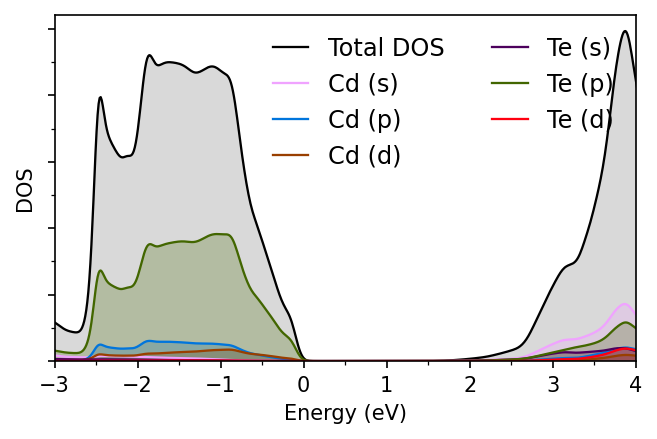

In [ ]:
dos_plotting.plot_dos(filename=f'{optics_directory}/vasprun.xml', xmin=-3, xmax=4, gaussian=0.05, save=False)

### Optical Absorption Spectrum

In [ ]:
optics.plot_absorption(filename=f'{optics_directory}/vasprun.xml', xmax=5, directory="test")

In [ ]:
from sumo.cli.optplot import optplot

optplot(modes=["n_real"], filenames=f'{optics_directory}/vasprun.xml', xmin=0, xmax=10, ymax=5, gaussian=0.1)

##### Optical/High-Frequency/Static Dielectric Constant

In [28]:
eps_inf, eps_inf_tensor, _, _, _ = optics.calc_dielectric(filename=f'{optics_directory}/vasprun.xml')

print("E_∞:", eps_inf)

print("")
print("E_∞ tensor:")
print(eps_inf_tensor)

E_∞: 6.5274

E_∞ tensor:
[[ 6.5274 -0.     -0.    ]
 [-0.      6.5274  0.    ]
 [-0.      0.      6.5274]]


### Band Structure

Band Gap = 0.5486 eV, \Gamma-\Gamma


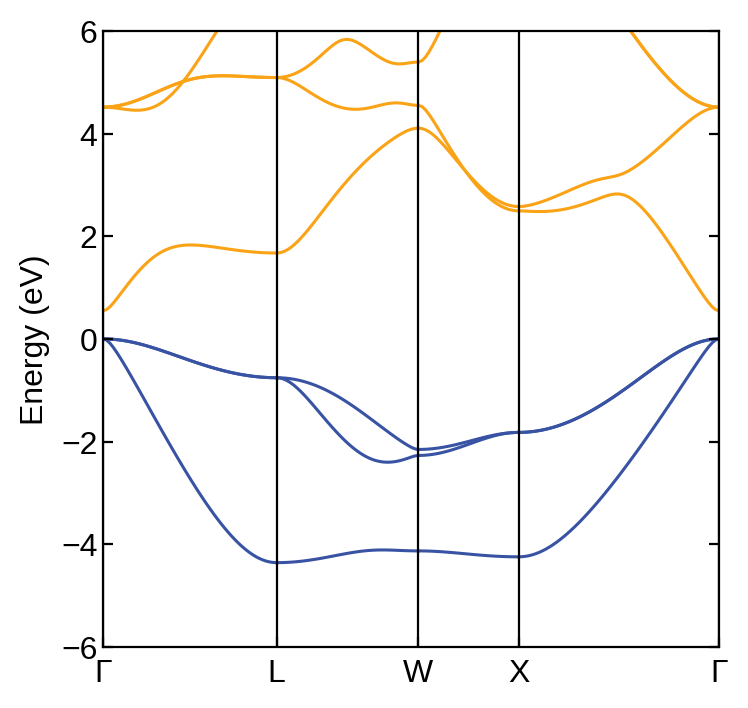

In [ ]:
#Extract (and recombine) vaspruns to create a single band structure object
bs = band_structure.get_band_structure(band_directory, splits)

#Plot the band structure, with the DOS alongside if desired
fig, ax = plt.subplots(figsize=(4,4), dpi=200)
band_structure.plot_band_structure(bs, plt, ymin=-6, ymax=6)

#Extract the band gap for use in the FOM and report it
band_gap = bs.get_band_gap()
E_gap = band_gap["energy"]
print(f"Band Gap = {E_gap} eV, {band_gap["transition"]}")

#Get the band-edge effective masses

## Calculating the SLME and Blank et al. metrics

In [21]:
# Generates a n_real.dat for use in SLME and Blank et al

filename = f'{optics_directory}/vasprun.xml'
optics.generate_n_real(filename)

In [23]:
# Use adapted blank metric code to generate flat_eta_out & lamb_eta_out

spectrum_type = "AM1.5" # One of "AM1.5", "Fluorescent", "Blue LED", "Green LED", "Red LED", "White LED", "IR LED", "Photopic"

spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)
photon_spectrum = db_fom.convert_spectrum(spectrum)          #Fix spectrum read error and work out which spectrum is required. 
optics.blank_calculate(photon_spectrum, optics_directory)

/home/owner/scripts/PV-FoM/solphin/optics.py:149: RuntimeWarning: invalid value encountered in divide
  phibb = 2*np.divide(np.divide(np.multiply(E,E),((h**3)*(c**2))),(np.exp(E/kT)-1))
/home/owner/scripts/PV-FoM/solphin/optics.py:132: RuntimeWarning: invalid value encountered in multiply
  T = np.exp((-x)) - np.multiply(x, np.exp((-x))) + (x**2*sc.exp1(x))


In [33]:
direct = 0.14# Direct Bandgap of your material from the band_std
indir= 0.15 # Indirect Bandgap of your material from the band_std (if none given use the direct bandgap twice)      #Wrap around sumo-bandstats?

#Get energy and absorption form absorption.dat. Get from sumo-optplot
# abs_file = f'{optics_directory}/absorption.dat'
abs_file = 'absorption_Imm2_Cu2GeSe3.dat'

spectral_average, spectral_dispersion = spectral.generate_spectral_parameters(abs_file, spectrum, E_gap=direct)

print("Spectral average (alpha):", spectral_average, "cm⁻¹")
print("Spectral dispersion (sigma):", spectral_dispersion)

Spectral average (alpha): 235736.2204403675 cm⁻¹
Spectral dispersion (sigma): 0.28221443666427715


### SLME

In [ ]:
energy, alpha_cm = spectral.load_absorption(abs_file)

print(energy)

#Test to see if this works for a specific thickness
data = slme.slme(energy, alpha_cm, direct, indir, thickness=1e-05, absorbance_in_inverse_centimeters=True)

print(data)

# Now run for multiple thicknesses 

thickness = np.logspace(-8, -3, 100, endpoint=True)
effSlm = []

for i in thickness:
    eff = data = slme.slme(energy, alpha_cm, direct, indir, thickness=i, absorbance_in_inverse_centimeters=True)
    effSlm.append(eff)

# Plot the SLME results

# ax = plt.axes()
# plt.plot(thickness, effSlm)
# plt.xscale('log')
# plt.margins(x=0)
# plt.ylim([0, 35])
# plt.xlabel('Film Thickness / m', labelpad=5)
# plt.ylabel('Max PV Efficiency $(\eta_{Max})$ / %')
# ax.set_aspect(0.06)
# plt.savefig('slme.pdf', format='pdf')

# You should have ran the Blank_Metric module from github - Chris Savory and have flat_eta_out and lamb_eta_out files

print('Running full Blank SLME plot')

lamb = np.loadtxt('lamb_eta_out', skiprows=0)
thickness_lamb = lamb[:,0]
eff_lamb = [x*100 for x in lamb[:,1]]

flat = np.loadtxt('flat_eta_out', skiprows=0)
thickness_flat = flat[:,0]
eff_flat = [x*100 for x in flat [:,1]]

fig, ax = plt.subplots(figsize=(6,4))
plt.plot(thickness, effSlm, label = 'SLME')
plt.plot(thickness_lamb, eff_lamb, label = 'Blank et al, Lambertian Surface')
plt.plot(thickness_flat, eff_flat, label = 'Blank et al, Flat Surface')
plt.xscale('log')
plt.margins(x=0)
plt.ylim([0, 35])
ax.set_aspect(0.06)
plt.legend()
plt.savefig('slme_blank_comparison.pdf', format='pdf')
# plt.show()

## Obtaining the Detailed Balance and Shockley-Queisser Limit

By supplying a band gap (eV) and operating temperature (K), the Detailed Balance results can be obtained and plotted.

In [9]:
# Define the operating temperature of the cell and Fundamental band gap (?)

Tcell = 300             # Operating Temperature
Egap = 1.45             # Using CdTe value
spectrum_type = "AM1.5" # One of "AM1.5", "Fluorescent", "Blue LED", "Green LED", "Red LED", "White LED", "IR LED", "Photopic"

# Convert the spectrum

spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)
photon_spectrum = db_fom.convert_spectrum(spectrum)

This can also be done interactively:

interactive(children=(FloatSlider(value=1.6, description='Band Gap (eV)', layout=Layout(width='800px'), max=3.…

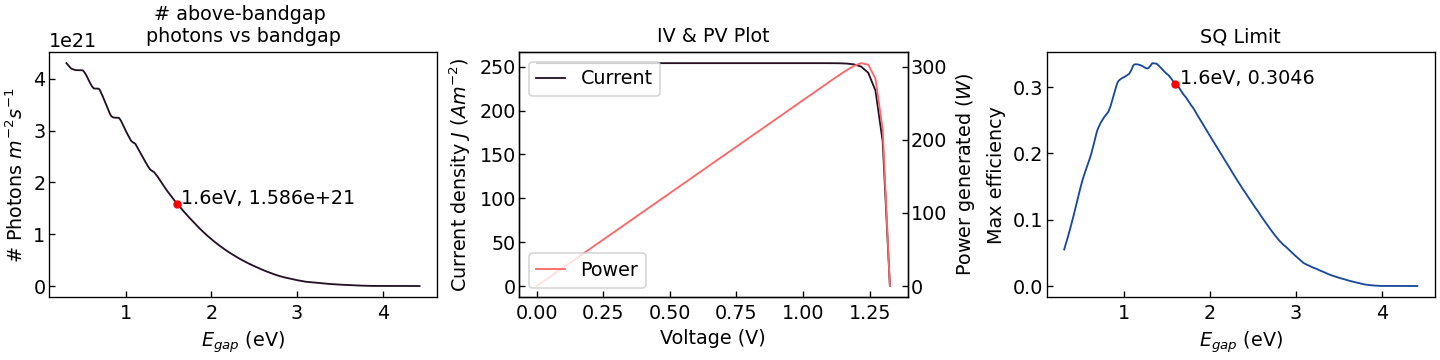

In [41]:
%matplotlib widget
db_plotting.plot_db_combined_interactive()

## Calculating The Photovoltaic Figure of Merit

This section brings together various properties to calculate the Photovoltaic Figure of Merit. Some of these must be manually specified - taken from other sources or representative values. Any of the calculated values from previous sections can be manually overwritten.

In [ ]:
# Taken from the previous sections of the notebook (can be overwritten)

# E_gap =                 # E₉ Electronic Band gap (eV)
# eps_inf =               # E_∞ Electronic/Optical/Static dielectric constant (unitless)
# spectral_average =      # Spectral average (alpha), (cm⁻¹)
# spectral_dispersion =   # Spectral dispersion (sigma), (unitless)
# dos_mass =              # m density of states effective mass (m₀)

In [ ]:
# Must be manually specified

tau = 2.5e-7              # Carrier lifetime (s)
mu = 10                   # Carrier mobility (cm²V⁻¹s⁻¹)
dopant_density = 1e16     # Dopant density (cm⁻³)

#Calculate the FoM using the efficiency metric
fom = final_results.Crovetto_efficiency(E_gap, photon_spectrum, spectral_average, tau, spectral_dispersion, dos_mass, dopant_density, eps_inf, mu, Tcell)
print(f"Photovoltaic Figure of Merit: {fom:.2f}")

In [ ]:
# The manual input parameters can be changed interactively to see how they affect the FoM.